# **Dense Neural Networks for Regression**

In this Jupyter Notebook, we'll learn how to apply a dense (fully-connected) neural network to a tabular dataset using TensorFlow (Keras). We will cover:
- Loading a tabular dataset (California Housing dataset from `scikit-learn` -- [link to Kaggle](https://www.kaggle.com/datasets/camnugent/california-housing-prices)).
- Splitting the dataset into training and test sets.
- Normalizing input features.
- Designing a neural network architecture for regression.
- Understanding concepts like underfitting, overfitting, and regularization.
- Using different activation functions.
- Monitoring and visualizing training progress.
- Evaluating model performance.

Let's get started!


## Importing the necessary libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


## Loading and inspecting the dataset

Here, we:
1. Load the California Housing dataset using `fetch_california_housing`.
2. Convert it to a `pandas.DataFrame` for easy manipulation.
3. Inspect the first few rows to understand our data.


In [3]:
california_housing = fetch_california_housing()
data = pd.DataFrame(california_housing.data, columns=california_housing.feature_names)
data['target'] = california_housing.target

data

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


## Understanding the dataset

We'll describe the dataset using descriptive statistics to get a sense of:
- Mean, std, min, and max values of features.
- Confirm there are no missing values.


In [4]:
data.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## Splitting the data into training, validation, and test sets

- We'll separate features (X) from the target values (y).
- We'll create a separate test set and also a validation set from the training data to help detect overfitting.


In [5]:
X = data.drop('target', axis=1)
y = data['target']

# First split off the test set
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, 
                                                              test_size=0.2,
                                                              random_state=42)

# Then split the remaining data into train and validation
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full,
                                                  test_size=0.2,
                                                  random_state=42)

print(f"Training set: {X_train.shape}, {y_train.shape}")
print(f"Validation set: {X_val.shape}, {y_val.shape}")
print(f"Test set: {X_test.shape}, {y_test.shape}")

Training set: (13209, 8), (13209,)
Validation set: (3303, 8), (3303,)
Test set: (4128, 8), (4128,)


## Normalizing (scaling) the features

Neural networks often work better when input features are scaled. We'll use `StandardScaler` to:
- Fit on the training set.
- Transform the training, validation, and test sets.


In [6]:
scaler = StandardScaler()
scaler.fit(X_train)  # Fit on the training set

# Transform all splits
X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Confirm the transformation by checking mean and std of the scaled training set
print("Mean of scaled training features:", X_train_scaled.mean(axis=0))
print("Std of scaled training features:", X_train_scaled.std(axis=0))

Mean of scaled training features: [ 1.12425946e-16 -5.83646656e-17  1.79128421e-16 -7.15437837e-17
  1.93652347e-17  4.41097012e-17 -1.17590008e-15  5.77030201e-15]
Std of scaled training features: [1. 1. 1. 1. 1. 1. 1. 1.]


## Building a basic dense neural network model

Here, we'll:
1. Use the Keras Sequential API.
2. Create a few Dense layers with nonlinear activation functions (e.g., ReLU).
3. Conclude with an output layer that produces a single value for regression.
4. Discuss the concept of underfitting vs. overfitting with layer sizes and depth.

In [7]:
# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Build the model
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=[X_train.shape[1]]),
    layers.Dense(64, activation='relu'),
    layers.Dense(1)  # Single output for regression
])

model.compile(
    loss='mse',
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    metrics=['mae']  # Mean Absolute Error
)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                576       
                                                                 
 dense_1 (Dense)             (None, 64)                4160      
                                                                 
 dense_2 (Dense)             (None, 1)                 65        
                                                                 
Total params: 4801 (18.75 KB)
Trainable params: 4801 (18.75 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


## Training the model

Now, we'll train the model on our scaled training data. We'll also monitor validation loss and mae to see how our model performs on unseen data.
- `epochs`: how many times the model sees the entire training set.
- `batch_size`: how many samples are processed before the model's internal parameters are updated.
- We'll store the training history to visualize overfitting or underfitting.


In [8]:
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
413/413 [==============================] - 4s 5ms/step - loss: 0.8634 - mae: 0.6252 - val_loss: 0.5053 - val_mae: 0.4936
Epoch 2/50
413/413 [==============================] - 1s 3ms/step - loss: 0.3968 - mae: 0.4451 - val_loss: 0.4510 - val_mae: 0.4529
Epoch 3/50
413/413 [==============================] - 2s 4ms/step - loss: 0.3746 - mae: 0.4270 - val_loss: 0.5808 - val_mae: 0.4413
Epoch 4/50
413/413 [==============================] - 2s 4ms/step - loss: 0.3750 - mae: 0.4212 - val_loss: 0.5507 - val_mae: 0.4361
Epoch 5/50
413/413 [==============================] - 2s 5ms/step - loss: 0.3520 - mae: 0.4103 - val_loss: 0.3576 - val_mae: 0.4208
Epoch 6/50
413/413 [==============================] - 2s 4ms/step - loss: 0.3247 - mae: 0.3987 - val_loss: 0.3721 - val_mae: 0.4152
Epoch 7/50
413/413 [==============================] - 2s 4ms/step - loss: 0.3182 - mae: 0.3936 - val_loss: 0.3612 - val_mae: 0.4053
Epoch 8/50
413/413 [==============================] - 1s 3ms/step - loss: 0.

## Visualizing training curves

We will plot the training and validation loss (MSE) and MAE to see if the model is overfitting or underfitting.
- If validation loss starts increasing while training loss decreases, that's a sign of overfitting.
- If both remain high, it could be underfitting.

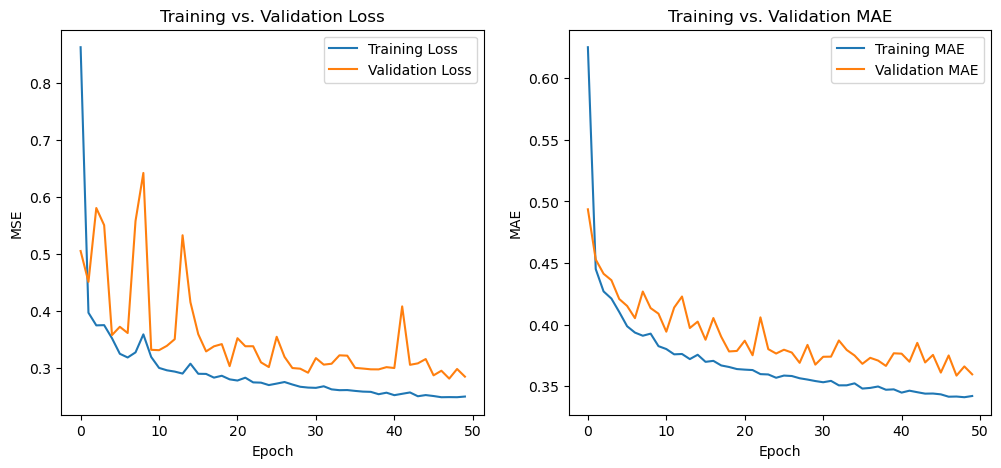

In [9]:
hist = pd.DataFrame(history.history)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(hist['loss'], label='Training Loss')
axes[0].plot(hist['val_loss'], label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].set_title('Training vs. Validation Loss')

axes[1].plot(hist['mae'], label='Training MAE')
axes[1].plot(hist['val_mae'], label='Validation MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].set_title('Training vs. Validation MAE')

plt.show()

## Evaluating on the test set

Once we're satisfied with the model performance on the validation set, we can evaluate it on the test set to get an unbiased measure of performance.


In [10]:
test_mse, test_mae = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test MSE: {test_mse:.4f}")
print(f"Test MAE: {test_mae:.4f}")

Test MSE: 0.2761
Test MAE: 0.3539


## Addressing overfitting with regularization

If we observe overfitting, we can:
1. Add dropout layers.
2. Add L2 regularization.
3. Reduce the network's capacity (fewer layers or fewer neurons).

Let's try adding dropout and L2 regularization to reduce overfitting.


In [11]:
tf.random.set_seed(42)
np.random.seed(42)

# Define L2 regularization factor
l2_reg = keras.regularizers.l2(0.001)

model_reg = keras.Sequential([
    layers.Dense(64, activation='relu', 
                 kernel_regularizer=l2_reg,
                 input_shape=[X_train.shape[1]]),
    layers.Dropout(0.2),  # Dropout with 20% rate
    layers.Dense(64, activation='relu', kernel_regularizer=l2_reg),
    layers.Dropout(0.2),
    layers.Dense(1, kernel_regularizer=l2_reg)
])

model_reg.compile(
    loss='mse',
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    metrics=['mae']
)

model_reg.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 64)                576       
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_4 (Dense)             (None, 64)                4160      
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense_5 (Dense)             (None, 1)                 65        
                                                                 
Total params: 4801 (18.75 KB)
Trainable params: 4801 (18.75 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


## Training the regularized model

We'll train our regularized model in the same way and compare results.

Epoch 1/50
413/413 [==============================] - 5s 8ms/step - loss: 1.1389 - mae: 0.7041 - val_loss: 0.6156 - val_mae: 0.5011
Epoch 2/50
413/413 [==============================] - 3s 7ms/step - loss: 0.6044 - mae: 0.5264 - val_loss: 0.4908 - val_mae: 0.4684
Epoch 3/50
413/413 [==============================] - 3s 8ms/step - loss: 0.5593 - mae: 0.4974 - val_loss: 0.4761 - val_mae: 0.4439
Epoch 4/50
413/413 [==============================] - 3s 6ms/step - loss: 0.5102 - mae: 0.4806 - val_loss: 0.4537 - val_mae: 0.4398
Epoch 5/50
413/413 [==============================] - 1s 3ms/step - loss: 0.4976 - mae: 0.4699 - val_loss: 0.5006 - val_mae: 0.4404
Epoch 6/50
413/413 [==============================] - 1s 2ms/step - loss: 0.4719 - mae: 0.4580 - val_loss: 0.4920 - val_mae: 0.4344
Epoch 7/50
413/413 [==============================] - 1s 3ms/step - loss: 0.4633 - mae: 0.4549 - val_loss: 0.5092 - val_mae: 0.4293
Epoch 8/50
413/413 [==============================] - 1s 2ms/step - loss: 0.

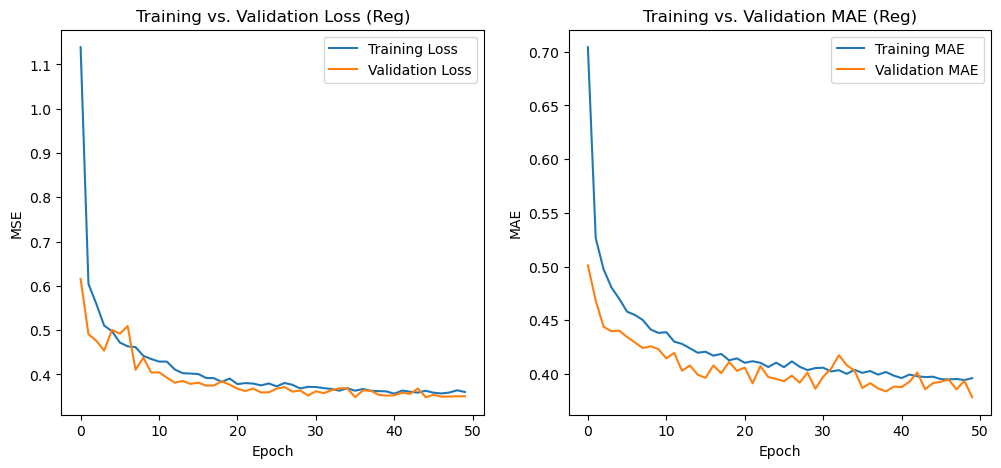

Test MSE (Regularized Model): 0.3370
Test MAE (Regularized Model): 0.3676


In [12]:
history_reg = model_reg.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=32,
    verbose=1
)

# Visualize losses again
hist_reg = pd.DataFrame(history_reg.history)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(hist_reg['loss'], label='Training Loss')
axes[0].plot(hist_reg['val_loss'], label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].set_title('Training vs. Validation Loss (Reg)')

axes[1].plot(hist_reg['mae'], label='Training MAE')
axes[1].plot(hist_reg['val_mae'], label='Validation MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].set_title('Training vs. Validation MAE (Reg)')

plt.show()

# Evaluate on the test set
test_mse_reg, test_mae_reg = model_reg.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test MSE (Regularized Model): {test_mse_reg:.4f}")
print(f"Test MAE (Regularized Model): {test_mae_reg:.4f}")